# Phishing Website Detection — Character CNN + Ensemble Classifiers (Kept Protocols)

This notebook builds a phishing URL detector using a character-level CNN as a feature extractor, followed by three tree-based ensemble classifiers trained on the learned features: **Random Forest**, **XGBoost**, and **LightGBM**. All three are trained and evaluated under identical conditions, and the best-performing model is selected automatically.

**Approach**

1. Learn a character-level representation of raw URLs using a 1D CNN (no manual feature engineering).
2. Extract a feature vector from the **deepest** convolutional block of the CNN.
3. Train Random Forest, XGBoost, and LightGBM classifiers on that feature set, and compare them on the held-out test set.

**Why this architecture makes sense**

- CNNs are good at learning *local* character patterns (e.g. character n-grams that look like `paypal-`, `.tk`, `login-secure-`, IP-like octets, etc.) without anyone having to hand-craft them.
- Tree-based ensembles are strong, low-variance classifiers on top of a *fixed* feature representation, and they are cheap to train compared to fine-tuning a deep net further.
- Comparing Random Forest, XGBoost, and LightGBM lets us pick whichever ensemble generalizes best on this feature set, rather than assuming one architecture is always the right choice.

This notebook is written to be **clean and modular**: every section is self-contained, uses standard PyTorch / scikit-learn idioms, and is documented with the *reasoning* behind each choice.

## 1. Imports

In [1]:
# --- Standard library ---
import os
import gc
import json
import pickle
import random
import time
from collections import Counter

# --- Data handling ---
import numpy as np
import pandas as pd

# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --- scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

# --- Gradient-boosted tree ensembles ---
import xgboost as xgb
import lightgbm as lgb

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Progress bars ---
from tqdm.auto import tqdm

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Configuration

All hyperparameters and paths live in a single `CONFIG` dictionary. This makes the notebook easy to tweak (e.g. for a hyperparameter sweep) and easy to save alongside the trained artifacts, so a saved model is always reproducible.

We also fix random seeds everywhere (Python, NumPy, PyTorch) for reproducibility.

In [2]:
CONFIG = {
    # --- Data ---
    "data_path": "/content/drive/MyDrive/phishing_detection_project/cleaned_phishing_dataset.csv",
    "output_dir": "/content/drive/MyDrive/phishing_detection_project/artifacts",
    "features_dir": "/content/drive/MyDrive/phishing_detection_project/artifacts/features",
    "url_col": "url",
    "label_col": "label",

    # --- Splits ---
    "test_size": 0.15,      # held-out test set
    "val_size": 0.15,       # taken from the remaining train set
    "random_state": 42,

    # --- URL encoding ---
    "max_url_len": 200,     # truncate / pad all URLs to this length
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",

    # --- CNN architecture ---
    "embedding_dim": 64,
    "num_filters": 256,
    "kernel_sizes": [7, 5, 3],   # one Conv1d block per kernel size -> shallow/middle/deep taps
    "feature_pool_size": 4,      # adaptive max-pool output size used for extracted features
    "fc_hidden_dim": 128,
    "num_classes": 2,            # 0 = phishing, 1 = legitimate
    "dropout": 0.3,

    # --- CNN training ---
    "batch_size": 256,
    "num_epochs": 20,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "early_stopping_patience": 3,

    # --- Random Forest ---
    "rf_n_estimators": 200,
    "rf_max_depth": 20,
    "rf_n_jobs": -1,
    "rf_class_weight": "balanced",  # dataset is imbalanced (~2:1 legit:phishing)

    # --- XGBoost --- (histogram-based splitting keeps this fast even with many trees)
    "xgb_n_estimators": 300,
    "xgb_max_depth": 6,
    "xgb_learning_rate": 0.05,
    "xgb_subsample": 0.9,
    "xgb_colsample_bytree": 0.9,
    "xgb_tree_method": "hist",
    "xgb_n_jobs": -1,

    # --- LightGBM --- (leaf-wise growth + histogram splitting; fast and accurate on tabular features)
    "lgbm_n_estimators": 300,
    "lgbm_num_leaves": 63,
    "lgbm_max_depth": 10,
    "lgbm_learning_rate": 0.05,
    "lgbm_subsample": 0.9,
    "lgbm_colsample_bytree": 0.9,
    "lgbm_n_jobs": -1,
}

SEED = CONFIG["random_state"]


def set_seed(seed: int = 42):
    """Fix random seeds across all libraries used for stochastic behaviour."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# --- Device selection: use GPU automatically if available, CPU otherwise ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Google Drive

We mount Google Drive so that the dataset can be read from it and all artifacts (model weights, plots, vocabulary, etc.) can be persisted there — this way nothing is lost when the Colab runtime is recycled.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(CONFIG["features_dir"], exist_ok=True)
print(f"Artifacts will be saved to: {CONFIG['output_dir']}")
print(f"Extracted features will be cached in: {CONFIG['features_dir']}")

Mounted at /content/drive
Artifacts will be saved to: /content/drive/MyDrive/phishing_detection_project/artifacts
Extracted features will be cached in: /content/drive/MyDrive/phishing_detection_project/artifacts/features


## 4. Data Loading

The dataset has two columns: `url` and `label`, where `label = 0` means **phishing** and `label = 1` means **legitimate**. The labels are already correct, so we do **not** invert them anywhere in this notebook.

We do a quick sanity check on the class distribution and on missing values, even though the dataset is described as already cleaned — this is good practice and costs almost nothing.

In [4]:
df = pd.read_csv(CONFIG["data_path"])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (781900, 2)


,url,label
0,https://www.google.com,1
1,https://www.youtube.com,1
2,https://www.facebook.com,1
3,https://www.baidu.com,1
4,https://www.wikipedia.org,1


In [5]:
# Sanity checks (cheap, and catches silent data issues early)
print("Missing values per column:")
print(df.isna().sum())

print("\nClass distribution:")
print(df[CONFIG["label_col"]].value_counts())
print(df[CONFIG["label_col"]].value_counts(normalize=True).rename("proportion"))

# Drop exact duplicate URLs if any slipped through, to avoid leakage between splits
before = len(df)
df = df.drop_duplicates(subset=[CONFIG["url_col"]]).reset_index(drop=True)
print(f"\nDropped {before - len(df)} duplicate URL rows.")

Missing values per column:
url      0
label    0
dtype: int64

Class distribution:
label
1    529190
0    252710
Name: count, dtype: int64
label
1    0.6768
0    0.3232
Name: proportion, dtype: float64

Dropped 0 duplicate URL rows.


## 6. Train / Validation / Test Split

We split the data **before** building the character vocabulary, and we build the vocabulary **only from the training set**. This mirrors how the model would behave in production, where it must handle characters it may not have explicitly seen during training (handled via the `<UNK>` token).

We use **stratified** splits so that the phishing/legitimate ratio (~1:2) is preserved across train, validation, and test sets — important given the class imbalance.

In [6]:
X = df[CONFIG["url_col"]].values
y = df[CONFIG["label_col"]].values

# First split off the test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=SEED,
)

# Then split the remainder into train / validation
val_ratio_of_remaining = CONFIG["val_size"] / (1 - CONFIG["test_size"])
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=val_ratio_of_remaining,
    stratify=y_train_full,
    random_state=SEED,
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    prop = np.mean(y_split == 1)
    print(f"{name}: legitimate ratio = {prop:.3f}")

Train: 547,329 | Val: 117,286 | Test: 117,285
Train: legitimate ratio = 0.677
Val: legitimate ratio = 0.677
Test: legitimate ratio = 0.677


## 7. Character Vocabulary & Encoding

**Steps:**

1. Build a character-level vocabulary automatically from the **training** URLs only (letters, digits, symbols that actually occur). This avoids hard-coding an alphabet and adapts to whatever character set the dataset actually uses.
2. Reserve index `0` for `<PAD>` (used to pad short URLs) and index `1` for `<UNK>` (used for any character seen at inference time that never appeared in training).
3. Encode every URL into a fixed-length sequence of integer character indices:
   - Truncate URLs longer than `max_url_len` (200) characters.
   - Pad shorter URLs with the `<PAD>` index.

Character-level encoding (as opposed to word/token-level) is what allows the CNN to learn directly from raw URL text without any manual feature engineering — it can pick up on sub-word patterns like repeated hyphens, digit sequences, suspicious TLDs, etc.

In [7]:
def build_vocab(urls, pad_token="<PAD>", unk_token="<UNK>"):
    """Build a character -> index mapping from a collection of URLs."""
    charset = set()
    for url in urls:
        charset.update(url)

    # Sort for a deterministic, reproducible ordering
    chars = sorted(charset)

    char2idx = {pad_token: 0, unk_token: 1}
    for ch in chars:
        char2idx[ch] = len(char2idx)

    idx2char = {idx: ch for ch, idx in char2idx.items()}
    return char2idx, idx2char


char2idx, idx2char = build_vocab(
    X_train, pad_token=CONFIG["pad_token"], unk_token=CONFIG["unk_token"]
)
vocab_size = len(char2idx)
PAD_IDX = char2idx[CONFIG["pad_token"]]
UNK_IDX = char2idx[CONFIG["unk_token"]]

print(f"Vocabulary size (incl. PAD/UNK): {vocab_size}")
print(f"PAD index: {PAD_IDX} | UNK index: {UNK_IDX}")

Vocabulary size (incl. PAD/UNK): 154
PAD index: 0 | UNK index: 1


In [8]:
def encode_url(url: str, char2idx: dict, max_len: int, unk_idx: int, pad_idx: int) -> np.ndarray:
    """Convert a URL string into a fixed-length array of character indices.

    - Characters not seen during vocabulary construction map to <UNK>.
    - URLs longer than max_len are truncated.
    - URLs shorter than max_len are right-padded with <PAD>.
    """
    encoded = [char2idx.get(ch, unk_idx) for ch in url[:max_len]]
    if len(encoded) < max_len:
        encoded = encoded + [pad_idx] * (max_len - len(encoded))
    return np.array(encoded, dtype=np.int64)


def encode_urls(urls, char2idx, max_len, unk_idx, pad_idx):
    """Vectorized helper: encode a list/array of URLs into a 2D array."""
    return np.stack([
        encode_url(u, char2idx, max_len, unk_idx, pad_idx) for u in urls
    ])


# Encode all three splits once, up front (fast, and avoids re-encoding every epoch)
X_train_enc = encode_urls(X_train, char2idx, CONFIG["max_url_len"], UNK_IDX, PAD_IDX)
X_val_enc = encode_urls(X_val, char2idx, CONFIG["max_url_len"], UNK_IDX, PAD_IDX)
X_test_enc = encode_urls(X_test, char2idx, CONFIG["max_url_len"], UNK_IDX, PAD_IDX)

print("Encoded shapes:", X_train_enc.shape, X_val_enc.shape, X_test_enc.shape)
print("Example encoded URL:\n", X_train_enc[0][:30], "...")

Encoded shapes: (547329, 200) (117286, 200) (117285, 200)
Example encoded URL:
 [75 87 87 83 86 29 18 18 83 88 69 16 27 28 71 25 21 25 19 71 71 26 22 72
 23 23 22 69 28 69] ...


## 8. PyTorch `Dataset` / `DataLoader`

A thin `Dataset` wrapper around the already-encoded arrays. Encoding is done once up front (above), so `__getitem__` is just an array lookup — this keeps data loading fast.

In [9]:
class PhishingURLDataset(Dataset):
    """Wraps pre-encoded character sequences and their labels."""

    def __init__(self, encoded_urls: np.ndarray, labels: np.ndarray):
        self.encoded_urls = torch.from_numpy(encoded_urls).long()
        self.labels = torch.from_numpy(np.asarray(labels)).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encoded_urls[idx], self.labels[idx]


train_dataset = PhishingURLDataset(X_train_enc, y_train)
val_dataset = PhishingURLDataset(X_val_enc, y_val)
test_dataset = PhishingURLDataset(X_test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 2139 | Val batches: 459 | Test batches: 459


## 9. Character-Level CNN

**Architecture:**

1. **Embedding layer** — maps each character index to a learned dense vector. This lets the model learn which characters behave similarly, rather than treating each character index as an unrelated category.
2. **Three stacked 1D convolutional blocks** (`Conv1d -> ReLU -> MaxPool1d`), with decreasing kernel sizes (7 -> 5 -> 3). Each block looks at progressively more abstract, longer-range patterns built on top of the previous block's output.
3. **Fully connected head** for classification (`Linear -> ReLU -> Dropout -> Linear`), trained with cross-entropy loss.

**Feature extraction for the ensemble classifiers:** after the third (deepest) convolutional block, we apply an `AdaptiveMaxPool1d` to a small fixed size (`feature_pool_size`) and flatten it. This gives us a fixed-length feature vector per URL, regardless of the exact sequence length at that point in the network. This is exactly the vector the Random Forest, XGBoost, and LightGBM models will be trained on later.

We keep the CNN as the *feature learner* — it is trained end-to-end with a classification head purely so that its internal representations become discriminative. The ensemble classifiers, not the CNN's own head, are the final classifiers.

In [10]:
class CharCNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        num_filters: int,
        kernel_sizes: list,
        fc_hidden_dim: int,
        num_classes: int,
        pad_idx: int,
        feature_pool_size: int = 4,
        dropout: float = 0.3,
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # One conv block per kernel size. "same"-ish padding keeps sequence length manageable.
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Conv1d(embedding_dim, num_filters, kernel_size=k1, padding=k1 // 2)
        self.conv2 = nn.Conv1d(num_filters, num_filters, kernel_size=k2, padding=k2 // 2)
        self.conv3 = nn.Conv1d(num_filters, num_filters, kernel_size=k3, padding=k3 // 2)

        self.pool = nn.MaxPool1d(kernel_size=2)

        # Adaptive pooling used specifically to produce a fixed-size feature vector
        # for the Random Forest, regardless of sequence length at the deepest block.
        self.feature_pool = nn.AdaptiveMaxPool1d(feature_pool_size)
        self.feature_dim = num_filters * feature_pool_size

        self.dropout = nn.Dropout(dropout)

        # Classification head, trained on the deepest representation.
        self.fc1 = nn.Linear(self.feature_dim, fc_hidden_dim)
        self.fc2 = nn.Linear(fc_hidden_dim, num_classes)

    def forward(self, x, return_features: bool = False):
        # x: (batch, seq_len) -> embedding -> (batch, seq_len, embed_dim)
        emb = self.embedding(x)
        emb = emb.transpose(1, 2)  # Conv1d expects (batch, channels, seq_len)

        h1 = self.pool(F.relu(self.conv1(emb)))   # shallow block
        h2 = self.pool(F.relu(self.conv2(h1)))    # middle block
        h3 = self.pool(F.relu(self.conv3(h2)))    # deep block

        # Fixed-size feature vector extracted at the deepest block only — this is
        # the only tap the Random Forest actually uses.
        deep_feat = self.feature_pool(h3).flatten(1)

        # Classification head (used only for training the CNN itself)
        x = self.dropout(deep_feat)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)

        if return_features:
            features = {"deep": deep_feat}
            return logits, features
        return logits


model = CharCNN(
    vocab_size=vocab_size,
    embedding_dim=CONFIG["embedding_dim"],
    num_filters=CONFIG["num_filters"],
    kernel_sizes=CONFIG["kernel_sizes"],
    fc_hidden_dim=CONFIG["fc_hidden_dim"],
    num_classes=CONFIG["num_classes"],
    pad_idx=PAD_IDX,
    feature_pool_size=CONFIG["feature_pool_size"],
    dropout=CONFIG["dropout"],
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {num_params:,}")
print(f"Feature vector dimension (deep features): {model.feature_dim}")

CharCNN(
  (embedding): Embedding(154, 64, padding_idx=0)
  (conv1): Conv1d(64, 256, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (feature_pool): AdaptiveMaxPool1d(output_size=4)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

Trainable parameters: 781,058
Feature vector dimension (deep features): 1024


## 10. CNN Training

**Choices and why:**

- **Loss:** `CrossEntropyLoss`, weighted by inverse class frequency to counteract the ~2:1 legitimate/phishing imbalance, so the model doesn't just learn to predict the majority class.
- **Optimizer:** `Adam` — a solid, low-maintenance default for this kind of model; no need for exotic optimizers here.
- **Early stopping:** we track validation loss and stop training if it doesn't improve for `early_stopping_patience` consecutive epochs, keeping the model that performed best on validation.
- **Checkpointing:** the best model (by validation loss) is saved to Google Drive after every improvement, so we never lose progress if the Colab runtime disconnects.

In [11]:
# Class weights for CrossEntropyLoss, computed from the training set only
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    [len(y_train) / (len(class_counts) * c) for c in class_counts],
    dtype=torch.float32,
).to(device)
print(f"Class counts (train): {class_counts} -> class weights: {class_weights.tolist()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]
)

Class counts (train): [176897 370432] -> class weights: [1.547027349472046, 0.7387712001800537]


In [12]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Runs one epoch of training (if optimizer is given) or evaluation."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == batch_y).sum().item()
            total_samples += batch_x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

In [13]:
checkpoint_path = os.path.join(CONFIG["output_dir"], "char_cnn_best.pt")
history_path = os.path.join(CONFIG["output_dir"], "training_history.json")

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

if os.path.exists(checkpoint_path):
    print(f"Found existing checkpoint:\n{checkpoint_path}")
    print("Loading saved model and skipping training...")

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )
    model.to(device)
    model.eval()

    # Reuse the training history saved alongside the checkpoint (if any), so the
    # loss/accuracy curves can still be plotted later without retraining.
    if os.path.exists(history_path):
        with open(history_path) as f:
            history = json.load(f)
        print(f"Loaded saved training history from {history_path}")
    else:
        print("No saved training history found alongside the checkpoint.")

else:
    print("No checkpoint found. Starting training...")

    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        start = time.time()

        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - start

        print(
            f"Epoch {epoch:02d}/{CONFIG['num_epochs']} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
            f"{elapsed:.1f}s"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0

            torch.save(model.state_dict(), checkpoint_path)
            print(f"  -> Validation loss improved. Checkpoint saved to {checkpoint_path}")

        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement} epoch(s).")

            if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
                print("Early stopping triggered.")
                break

    # Load the best model before feature extraction
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )

    # Save training history alongside the checkpoint so it can be reused for
    # plotting (see Section 14) without needing to retrain in a later run.
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)
    print(f"Training history saved to {history_path}")

model.eval()

Found existing checkpoint:
/content/drive/MyDrive/phishing_detection_project/artifacts/char_cnn_best.pt
Loading saved model and skipping training...
Loaded saved training history from /content/drive/MyDrive/phishing_detection_project/artifacts/training_history.json


CharCNN(
  (embedding): Embedding(154, 64, padding_idx=0)
  (conv1): Conv1d(64, 256, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (feature_pool): AdaptiveMaxPool1d(output_size=4)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

## 11. Feature Extraction (Memory-Efficient, Streamed to Disk)

Now that the CNN is trained, we freeze it and use it purely as a **feature extractor**: for every URL in each split, we run a forward pass and collect the deep feature vector defined in the model above. This becomes the input to the Random Forest classifier.

The previous version of this section still accumulated every batch's features into Python lists before a single `np.concatenate` call — for ~780,000 URLs that meant the lists (holding every batch) and the freshly concatenated, split-sized arrays briefly coexisted in RAM, which is what kept crashing the Colab runtime. This version removes that pattern entirely:

- **No feature lists, no `concatenate`.** Batches are written straight into their final destination as they're produced; there is no Python list accumulating batches and no `np.concatenate` call ever materializing a whole split at once.
- **`numpy.memmap` as the destination.** For each split we create fixed-size memory-mapped `.dat` files (`{split}_deep.dat`, `{split}_labels.dat`), each sized `(n_samples, feature_dim)` up front. A memmap behaves like a normal NumPy array to the code using it, but its contents live on disk — writing into a slice of it does not require the whole array to be resident in RAM.
- **One batch in RAM at a time.** Each batch's deep-feature tensor is copied directly into its memmap slice (`memmap[start:end] = ...`) and then discarded before the next batch is processed — at no point are two batches', let alone a whole split's, features held simultaneously.
- **Float16 on disk, periodic flush.** Feature values are cast to `float16` per batch (not per split) before being written; labels keep their original integer dtype. Every `flush_every` batches (and once more at the end) we call `.flush()` on the memmaps so writes are actually committed to disk rather than sitting in a buffer.
- **Resumable.** If a split's `.dat` files and metadata already exist, extraction is skipped entirely — restarting the notebook after a disconnect reuses cached features instead of recomputing them.
- **RAM freed before *and* after extraction.** Immediately before extraction we drop objects that were only needed for CNN training (optimizer state, loss, class weights). Immediately after extraction finishes, we drop the per-split `DataLoader`/`Dataset`/encoded-array objects — because of how `torch.from_numpy` shares memory with its source array, that's the first point at which freeing them actually releases RAM (see the comment in that cell for the full explanation).

The CNN itself only computes the deep tap now (see the `CharCNN.forward` change above), so there's no shallow/middle feature computation or on-disk storage to skip in the first place — the notebook no longer produces `{split}_shallow.dat` / `{split}_middle.dat` files at all.

In [14]:
# --- Free objects that were only needed for CNN training, before extraction starts ---
del optimizer, criterion, class_weights
gc.collect()
torch.cuda.empty_cache()  # release cached (but now-unused) CUDA memory blocks

print("Freed CNN-training-only objects (optimizer, loss, class weights).")

Freed CNN-training-only objects (optimizer, loss, class weights).


In [15]:
FEATURE_DIM = model.feature_dim  # deep feature vectors are this length
LABEL_DTYPE = y_train.dtype      # preserve the labels' original integer dtype on disk


def _memmap_paths(split_name, features_dir):
    """Returns the on-disk paths for one split's memmap feature files + metadata."""
    return {
        "deep": os.path.join(features_dir, f"{split_name}_deep.dat"),
        "labels": os.path.join(features_dir, f"{split_name}_labels.dat"),
        "meta": os.path.join(features_dir, f"{split_name}_meta.json"),
    }


def _memmap_cached(split_name, features_dir):
    """True if every file for this split (features + metadata) already exists."""
    paths = _memmap_paths(split_name, features_dir)
    return all(os.path.exists(p) for p in paths.values())


@torch.no_grad()
def extract_features_to_memmap(
    model, loader, split_name, n_samples, feature_dim, label_dtype, features_dir,
    flush_every=200, force_recompute=False,
):

    paths = _memmap_paths(split_name, features_dir)

    if not force_recompute and _memmap_cached(split_name, features_dir):
        print(f"Found cached memmap features for '{split_name}' split. Skipping extraction.")
        return

    print(f"Extracting {split_name} features (streaming to memmap)...")
    model.eval()

    # Create the on-disk array up front, at its final shape — no resizing/growth,
    # so there's never a "reallocate and copy the whole array" moment like a list has.
    deep_mm = np.memmap(paths["deep"], dtype=np.float16, mode="w+", shape=(n_samples, feature_dim))
    labels_mm = np.memmap(paths["labels"], dtype=label_dtype, mode="w+", shape=(n_samples,))

    start = 0
    for batch_idx, (batch_x, batch_y) in enumerate(tqdm(loader, desc=f"Extracting {split_name} features")):
        batch_x = batch_x.to(device)
        _, features = model(batch_x, return_features=True)

        end = start + batch_x.size(0)

        # Write straight into the memmap slice. Only this one batch's array exists
        # in RAM at this point; nothing from previous iterations is kept around.
        deep_mm[start:end] = features["deep"].cpu().numpy().astype(np.float16)
        labels_mm[start:end] = batch_y.numpy()

        start = end
        del features  # drop this batch's feature tensor before the next iteration

        # Periodic flush: pushes buffered writes for these arrays to disk so we're
        # not silently accumulating unwritten pages in memory as extraction proceeds.
        if (batch_idx + 1) % flush_every == 0:
            deep_mm.flush()
            labels_mm.flush()

    assert start == n_samples, f"Expected {n_samples} rows, wrote {start}."

    # Final flush guarantees every write is safely on disk before we close the files.
    deep_mm.flush()
    labels_mm.flush()

    # Save shape/dtype metadata so load_features_memmap() can reopen these files
    # later without needing to already know n_samples/feature_dim.
    with open(paths["meta"], "w") as f:
        json.dump(
            {"n_samples": n_samples, "feature_dim": feature_dim, "labels_dtype": str(label_dtype)},
            f,
        )

    # The data lives on disk now, not in RAM — dropping these references just closes
    # the file handles, there's no large array left to free here.
    del deep_mm, labels_mm
    gc.collect()

    print(f"{split_name.capitalize()} features saved to memmap.\n")


def load_features_memmap(split_name, features_dir, mode="r"):
    """Reopens a split's deep/labels memmap arrays for later use (e.g. Random Forest
    training/evaluation), without loading them into RAM.

    Opening with mode="r" maps the files read-only; scikit-learn only pulls the
    bytes it actually needs into RAM when it reads from these arrays.
    """
    paths = _memmap_paths(split_name, features_dir)
    with open(paths["meta"]) as f:
        meta = json.load(f)

    n_samples, feature_dim = meta["n_samples"], meta["feature_dim"]
    label_dtype = np.dtype(meta["labels_dtype"])

    return {
        "deep": np.memmap(paths["deep"], dtype=np.float16, mode=mode, shape=(n_samples, feature_dim)),
        "labels": np.memmap(paths["labels"], dtype=label_dtype, mode=mode, shape=(n_samples,)),
    }


# Extract (or reuse cached) features one split at a time, streamed straight to Drive.
extract_features_to_memmap(model, train_loader, "train", len(y_train), FEATURE_DIM, LABEL_DTYPE, CONFIG["features_dir"])
extract_features_to_memmap(model, val_loader, "val", len(y_val), FEATURE_DIM, LABEL_DTYPE, CONFIG["features_dir"])
extract_features_to_memmap(model, test_loader, "test", len(y_test), FEATURE_DIM, LABEL_DTYPE, CONFIG["features_dir"])

print("Feature extraction complete. Files on disk:")
print(sorted(os.listdir(CONFIG["features_dir"])))

Found cached memmap features for 'train' split. Skipping extraction.
Found cached memmap features for 'val' split. Skipping extraction.
Found cached memmap features for 'test' split. Skipping extraction.
Feature extraction complete. Files on disk:
['test_deep.dat', 'test_labels.dat', 'test_meta.json', 'train_deep.dat', 'train_labels.dat', 'train_meta.json', 'val_deep.dat', 'val_labels.dat', 'val_meta.json']


In [16]:
# --- Free per-split loaders/datasets/encoded arrays now that extraction is done ---

# Why it's safe now: every split's features are already written to the memmap files
# on disk. Nothing later in the notebook (Random Forest training, evaluation, plots,
# inference) touches `train_loader`, `val_loader`, `test_loader`, their Datasets, or
# the encoded arrays — they only read from the memmap files via `load_features_memmap`.
# This is therefore the first point where freeing these six objects actually reduces RAM.

del train_loader, val_loader, test_loader
del train_dataset, val_dataset, test_dataset
del X_train_enc, X_val_enc, X_test_enc
gc.collect()
torch.cuda.empty_cache()

print("Freed per-split DataLoaders/Datasets/encoded arrays after extraction.")

Freed per-split DataLoaders/Datasets/encoded arrays after extraction.


## 12. Random Forest, XGBoost & LightGBM Training

We train three tree-based ensemble classifiers on the **deep** CNN features (the output of the third/deepest convolutional block): **Random Forest**, **XGBoost**, and **LightGBM**.

**Why compare three ensembles?**

- Random Forest is a strong, low-variance bagging baseline that is simple to tune and resistant to overfitting.
- XGBoost and LightGBM are gradient-boosted tree ensembles that often reach higher accuracy than bagging alone on fixed feature vectors like these, while still training quickly.
- Each model is configured to be **fast** (histogram-based splitting, parallelized across all CPU cores, a moderate number of shallow-to-medium-depth trees) while keeping enough capacity to be **accurate** — no extensive hyperparameter search is needed since all three are working from the same fixed, already-informative CNN features.

All three models account for the same class imbalance handled earlier for the CNN: Random Forest and LightGBM use `class_weight="balanced"`, and XGBoost uses the equivalent `scale_pos_weight`, computed from the training labels.

Training reopens the on-disk `train_*.dat` memmap files via `load_features_memmap()` instead of reusing an in-memory dict, materializes the deep features into a real array once, fits all three models on it, saves each one, and then frees the array before moving on — so only one copy of the training features is ever resident in RAM at a time.

In [20]:
def load_or_train(model_path, train_fn, *train_args):
    if os.path.exists(model_path):
        print(f"Loading existing model: {model_path}")
        with open(model_path, "rb") as f:
            model = pickle.load(f)
    else:
        print(f"Training model: {os.path.basename(model_path)}")
        model = train_fn(*train_args)
        with open(model_path, "wb") as f:
            pickle.dump(model, f)
        print(f"Saved model to {model_path}")

    return model


# Load training features from memmap files into actual NumPy arrays
train_features = load_features_memmap("train", CONFIG["features_dir"])
X_feat = np.asarray(train_features["deep"], dtype=np.float32)
y_feat = np.asarray(train_features["labels"], dtype=np.int32)

print(f"Loaded training features shape: {X_feat.shape}")
print(f"Loaded training labels shape: {y_feat.shape}")


def train_random_forest(X_feat, y_labels, config, seed):
    rf = RandomForestClassifier(
        n_estimators=config["rf_n_estimators"],
        max_depth=config["rf_max_depth"],
        class_weight=config["rf_class_weight"],
        n_jobs=config["rf_n_jobs"],
        random_state=seed,
    )
    rf.fit(X_feat, y_labels)
    return rf


def train_xgboost(X_feat, y_labels, config, seed):
    # scale_pos_weight is XGBoost's equivalent of class_weight="balanced":
    # the ratio of negative to positive samples in the training set.
    n_pos = int((y_labels == 1).sum())
    n_neg = int((y_labels == 0).sum())
    scale_pos_weight = n_neg / n_pos

    model = xgb.XGBClassifier(
        n_estimators=config["xgb_n_estimators"],
        max_depth=config["xgb_max_depth"],
        learning_rate=config["xgb_learning_rate"],
        subsample=config["xgb_subsample"],
        colsample_bytree=config["xgb_colsample_bytree"],
        tree_method=config["xgb_tree_method"],   # "hist" -> fast, memory-efficient splitting
        scale_pos_weight=scale_pos_weight,
        n_jobs=config["xgb_n_jobs"],
        random_state=seed,
        eval_metric="logloss",
    )
    model.fit(X_feat, y_labels)
    return model


def train_lightgbm(X_feat, y_labels, config, seed):
    model = lgb.LGBMClassifier(
        n_estimators=config["lgbm_n_estimators"],
        num_leaves=config["lgbm_num_leaves"],
        max_depth=config["lgbm_max_depth"],
        learning_rate=config["lgbm_learning_rate"],
        subsample=config["lgbm_subsample"],
        colsample_bytree=config["lgbm_colsample_bytree"],
        class_weight="balanced",
        n_jobs=config["lgbm_n_jobs"],
        random_state=seed,
    )
    model.fit(X_feat, y_labels)
    return model



rf_path = os.path.join(CONFIG["output_dir"], "rf_deep.pkl")
xgb_path = os.path.join(CONFIG["output_dir"], "xgb_deep.pkl")
lgbm_path = os.path.join(CONFIG["output_dir"], "lgbm_deep.pkl")

rf_model = load_or_train(
    rf_path,
    train_random_forest,
    X_feat,
    y_feat,
    CONFIG,
    SEED,
)

xgb_model = load_or_train(
    xgb_path,
    train_xgboost,
    X_feat,
    y_feat,
    CONFIG,
    SEED,
)

lgbm_model = load_or_train(
    lgbm_path,
    train_lightgbm,
    X_feat,
    y_feat,
    CONFIG,
    SEED,
)

Loaded training features shape: (547329, 1024)
Loaded training labels shape: (547329,)
Loading existing model: /content/drive/MyDrive/phishing_detection_project/artifacts/rf_deep.pkl
Training model: xgb_deep.pkl
Saved model to /content/drive/MyDrive/phishing_detection_project/artifacts/xgb_deep.pkl
Training model: lgbm_deep.pkl
[LightGBM] [Info] Number of positive: 370432, number of negative: 176897
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 10.709361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 227041
[LightGBM] [Info] Number of data points in the train set: 547329, number of used features: 990
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Saved model to /content/drive/MyDrive/phishing_detection_project/artifacts/lgbm_deep.pkl


In [21]:
del X_feat, y_feat
print("Done.")

# The train-split features are no longer needed once all three models are fit.
del train_features
gc.collect()

Done.


377

In [22]:
def rf_predict_proba(model, feature_dict, depth="deep"):
    """Predicted probability of the positive class from a fitted classifier."""
    return model.predict_proba(np.asarray(feature_dict[depth], dtype=np.float32))[:, 1]


# Load only the validation split for this quick sanity check.
val_features = load_features_memmap("val", CONFIG["features_dir"])

candidate_models = {
    "RandomForest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
}

for name, mdl in candidate_models.items():
    val_pred = mdl.predict(np.asarray(val_features["deep"], dtype=np.float32))
    val_acc = accuracy_score(val_features["labels"], val_pred)
    print(f"Validation accuracy ({name} on deep features): {val_acc:.4f}")

# Free the validation-split features; they aren't needed again after this check.
del val_features
gc.collect()

Validation accuracy (RandomForest on deep features): 0.9820
Validation accuracy (XGBoost on deep features): 0.9811


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation accuracy (LightGBM on deep features): 0.9814


43

In [23]:
# The test split is needed for both evaluation (Section 13) and the plots
# (Section 14) below, so we load it once here and keep it in memory for that
# stretch of the notebook only — train/val features have already been freed.
test_features = load_features_memmap("test", CONFIG["features_dir"])
print(f"Test features loaded: { {k: v.shape for k, v in test_features.items()} }")

Test features loaded: {'deep': (117285, 1024), 'labels': (117285,)}


## 13. Evaluation on the Test Set & Model Selection

We evaluate Random Forest, XGBoost, and LightGBM on the held-out **test set** (never used for training or model selection), reporting the full set of standard classification metrics for each. We then select the best-performing model (by F1 score, since the dataset is imbalanced) to use for the visualizations and saved artifacts that follow.

In [24]:
def evaluate_predictions(y_true, y_proba, threshold=0.5, name="model"):
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }
    return metrics, y_pred


results = []
predictions_by_model = {}
proba_by_model = {}

for name, mdl in candidate_models.items():
    proba = rf_predict_proba(mdl, test_features)
    metrics, pred = evaluate_predictions(test_features["labels"], proba, name=name)
    results.append(metrics)
    predictions_by_model[name] = pred
    proba_by_model[name] = proba

results_df = pd.DataFrame(results).set_index("model")

# Pick the best model by F1 score (balances precision/recall on this imbalanced task).
best_model_name = results_df["f1"].idxmax()
best_model = candidate_models[best_model_name]
best_proba = proba_by_model[best_model_name]
best_pred = predictions_by_model[best_model_name]

print(f"Best model (by F1 score): {best_model_name}")
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best model (by F1 score): RandomForest


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
RandomForest,0.981703,0.988625,0.984291,0.986453,0.996889,0.998255
XGBoost,0.981310,0.990381,0.981922,0.986134,0.997090,0.998495
LightGBM,0.981379,0.990096,0.982313,0.986189,0.997065,0.998462


In [25]:
print(f"Classification report ({best_model_name}):\n")
print(classification_report(
    test_features["labels"], best_pred, target_names=["phishing (0)", "legitimate (1)"]
))

cm = confusion_matrix(test_features["labels"], best_pred)
print("Confusion matrix (rows=true, cols=predicted):")
print(cm)

Classification report (RandomForest):

                precision    recall  f1-score   support

  phishing (0)       0.97      0.98      0.97     37906
legitimate (1)       0.99      0.98      0.99     79379

      accuracy                           0.98    117285
     macro avg       0.98      0.98      0.98    117285
  weighted avg       0.98      0.98      0.98    117285

Confusion matrix (rows=true, cols=predicted):
[[37007   899]
 [ 1247 78132]]


## 14. Visualization

We plot:

- ROC curves and Precision-Recall curves for Random Forest, XGBoost, and LightGBM on the test set, overlaid for direct comparison.
- Confusion matrix heatmap for the best-performing model.

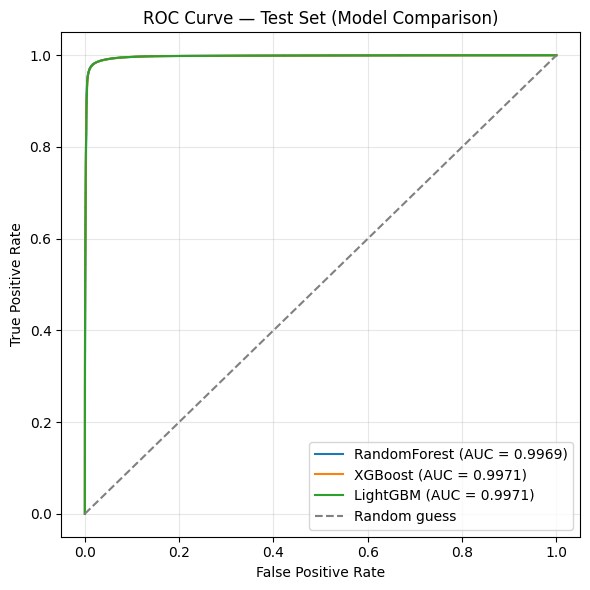

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in candidate_models:
    fpr, tpr, _ = roc_curve(test_features["labels"], proba_by_model[name])
    auc = roc_auc_score(test_features["labels"], proba_by_model[name])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set (Model Comparison)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "roc_curve.png"), dpi=150)
plt.show()

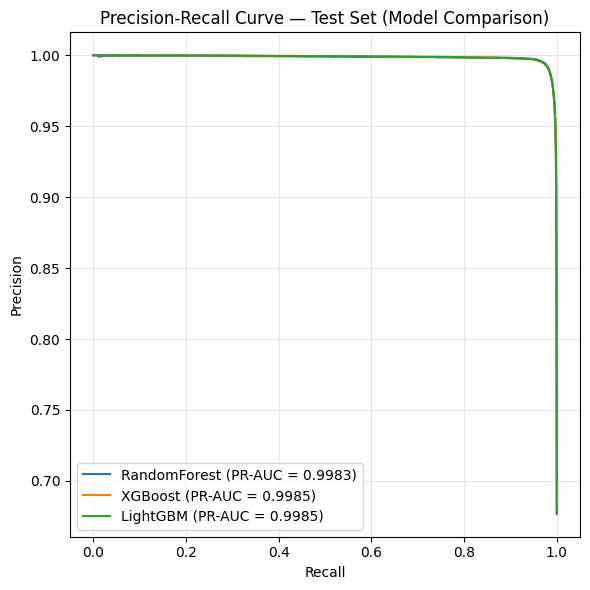

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
for name in candidate_models:
    precision, recall, _ = precision_recall_curve(test_features["labels"], proba_by_model[name])
    pr_auc = average_precision_score(test_features["labels"], proba_by_model[name])
    ax.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set (Model Comparison)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "pr_curve.png"), dpi=150)
plt.show()

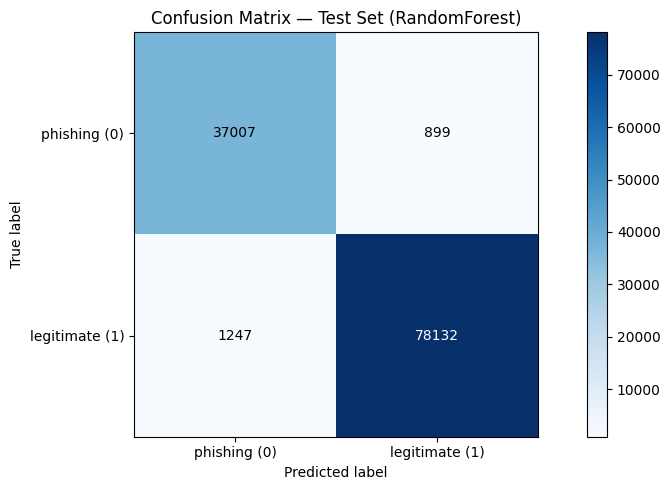

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["phishing (0)", "legitimate (1)"])
ax.set_yticklabels(["phishing (0)", "legitimate (1)"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix — Test Set ({best_model_name})")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "confusion_matrix.png"), dpi=150)
plt.show()

In [ ]:
def encode_url(url: str, char2idx: dict, max_len: int, unk_idx: int, pad_idx: int) -> np.ndarray:
    """Convert a URL string into a fixed-length array of character indices."""
    encoded = [char2idx.get(ch, unk_idx) for ch in url[:max_len]]
    if len(encoded) < max_len:
        encoded = encoded + [pad_idx] * (max_len - len(encoded))
    return np.array(encoded, dtype=np.int64)

def rf_predict_proba(model, feature_dict, depth="deep"):
    """Predicted probability of the positive class from a fitted classifier."""
    return model.predict_proba(np.asarray(feature_dict[depth], dtype=np.float32))[:, 1]

def predict_url(url: str, model, clf_model, char2idx: dict, config: dict, device):
    """End-to-end inference on a single raw URL string."""
    model.eval()

    # Encode using the saved vocabulary
    encoded = encode_url(
        url, char2idx, config["max_url_len"],
        unk_idx=char2idx[config.get("unk_token", "<UNK>")],
        pad_idx=char2idx[config.get("pad_token", "<PAD>")],
    )
    x = torch.from_numpy(encoded).long().unsqueeze(0).to(device)  # add batch dim

    with torch.no_grad():
        _, features = model(x, return_features=True)
        feature_dict = {k: v.cpu().numpy() for k, v in features.items()}

    proba_legit = rf_predict_proba(clf_model, feature_dict)[0]
    predicted_class = int(proba_legit >= 0.5)
    confidence = abs(proba_legit - 0.5) * 2  # rescale distance from boundary to [0, 1]

    label_name = "legitimate" if predicted_class == 1 else "phishing"

    return {
        "url": url,
        "predicted_class": predicted_class,
        "predicted_label": label_name,
        "probability_legitimate": float(proba_legit),
        "confidence": float(confidence),
    }

example_urls = [
    "https://www.google.com",  # Legitimate
    "https://www.paypaal.com/login",  # Phishing-like example (hypothetical)
    "https://mail.google.com/mail/u/0/#inbox", # Legitimate
    "http://bankofamerica-login.com.phishing.ru/secure/signin",  # Phishing-like example (hypothetical)
    "https://colab.research.google.com/", # Legitimate
    "http://facebook.com.verify.login.data.com/", # Phishing-like example (hypothetical)
    "https://secure-login.paypal.com.workers.dev/",  # Phishing-like example (hypothetical)
    "https://bit.ly/3xKp9Qz",  # Legitimate
    "https://bankofamerica.mfa-verify.net/", # Phishing-like example (hypothetical)
]

print(f"\n--- Inference Examples (using {best_model_name}) ---")
for url in example_urls:
    result = predict_url(url, model, best_model, char2idx, CONFIG, device)
    print(f"\nURL: {result['url']}")
    print(f"  Predicted Label: {result['predicted_label']} (Class: {result['predicted_class']})")
    print(f"  Probability Legitimate: {result['probability_legitimate']:.4f}")
    print(f"  Confidence: {result['confidence']:.4f}")


--- Inference Examples (using RandomForest) ---

URL: https://www.google.com
  Predicted Label: legitimate (Class: 1)
  Probability Legitimate: 0.9991
  Confidence: 0.9981

URL: https://www.paypaal.com/login
  Predicted Label: phishing (Class: 0)
  Probability Legitimate: 0.4206
  Confidence: 0.1587

URL: https://mail.google.com/mail/u/0/#inbox
  Predicted Label: phishing (Class: 0)
  Probability Legitimate: 0.1430
  Confidence: 0.7139

URL: http://bankofamerica-login.com.phishing.ru/secure/signin
  Predicted Label: phishing (Class: 0)
  Probability Legitimate: 0.0022
  Confidence: 0.9956

URL: https://colab.research.google.com/
  Predicted Label: legitimate (Class: 1)
  Probability Legitimate: 0.6248
  Confidence: 0.2496

URL: http://facebook.com.verify.login.data.com/
  Predicted Label: phishing (Class: 0)
  Probability Legitimate: 0.0009
  Confidence: 0.9982

URL: https://secure-login.paypal.com.workers.dev/
  Predicted Label: phishing (Class: 0)
  Probability Legitimate: 0.0934
  

### Analyzing Misclassified Legitimate URLs

In [31]:
# Identify misclassified legitimate URLs
misclassified_legitimate_indices = np.where(
    (test_features["labels"] == 1) & (best_pred == 0)
)[0]

misclassified_legitimate_urls = X_test[misclassified_legitimate_indices]

print(f"Number of legitimate URLs misclassified as phishing: {len(misclassified_legitimate_urls):,}")
print("\nExamples of misclassified legitimate URLs:")
for url in misclassified_legitimate_urls[:10]: # Display first 10 examples
    print(f"- {url}")

Number of legitimate URLs misclassified as phishing: 1,247

Examples of misclassified legitimate URLs:
- https://irs-tracking.mfs.gg/3pG0BH5
- https://www.pcionline.search4careercolleges.com/?affiliateid=5571&type=&adgroup=&kw=&acctid=&ovkey=pinnacle%20career%20institute%20online
- https://30minutesbreastlift.com/
- https://onlineaccess-centier.firebaseapp.com/
- https://userservicenetfiixsav.com/
- https://winvestment.ae/cgi-/blob.html
- https://drive.google.com/file/d/1UUoltqWAjCxhi940mH65TVepNpL5RS6i/view?usp=sharing
- http://jerrybeers.com
- http://www.purdiesolicitors.co.uk/bs9tpz$lkkkkbf511s$l$mxkwv$lny50$ml$lk3$lp$l0hd1$lkpzyx$lkkkkq
- https://my-ee-alert.web.app/


Now, let's extract character n-grams (e.g., 3-grams, 4-grams, 5-grams) from these misclassified legitimate URLs to see if there are any common character sequences that might be leading the model astray. This can highlight patterns that the CNN might be over-associating with phishing.

Extracting n-grams:   0%|          | 0/1247 [00:00<?, ?it/s]

/tmp/ipykernel_1231/1898944213.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='viridis')
/tmp/ipykernel_1231/1898944213.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='viridis')
/tmp/ipykernel_1231/1898944213.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='viridis')


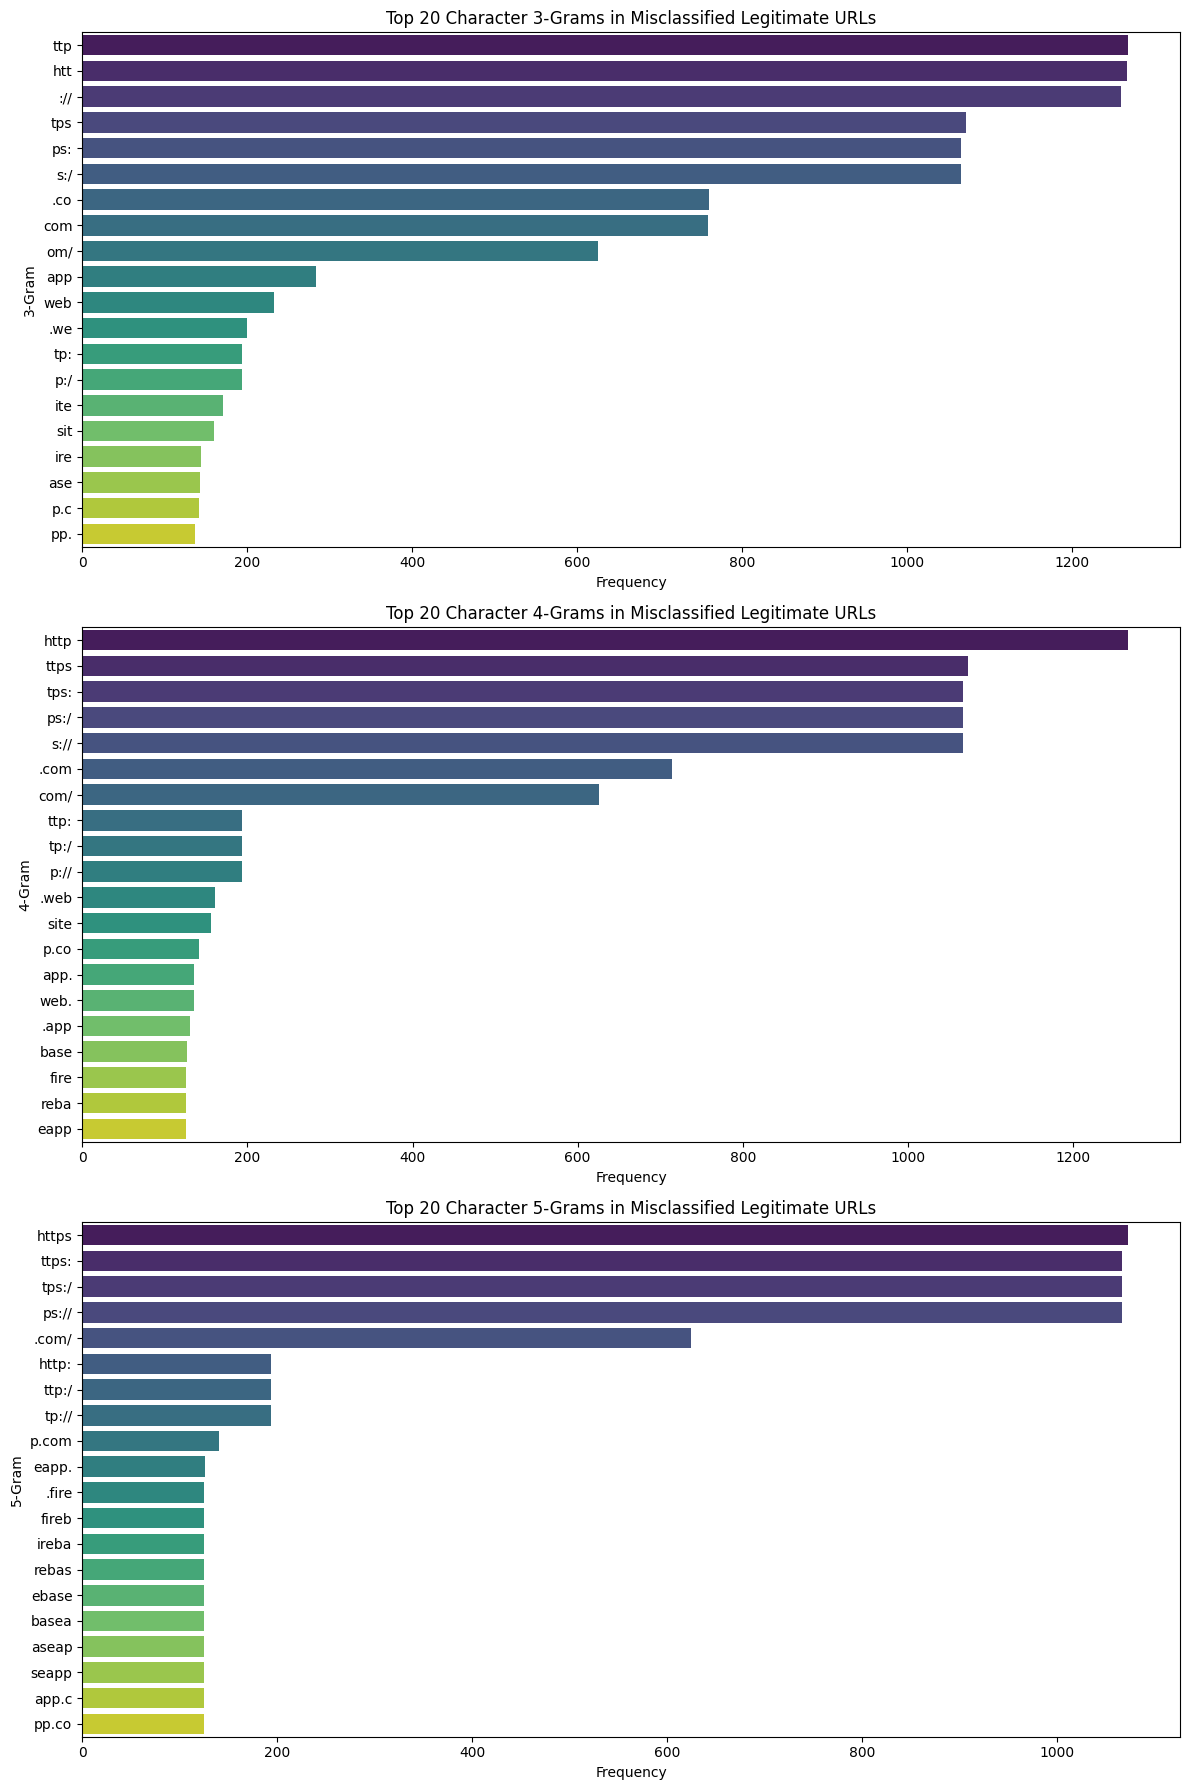

In [32]:
def extract_ngrams(text, n):
    """Extracts character n-grams from a given string."""
    return [text[i:i+n] for i in range(len(text) - n + 1)]

# Choose n-gram sizes to analyze
ngram_sizes = [3, 4, 5]

all_ngrams = {n: Counter() for n in ngram_sizes}

for url in tqdm(misclassified_legitimate_urls, desc="Extracting n-grams"):
    # Clean the URL first as done in preprocessing

    for n in ngram_sizes:
        all_ngrams[n].update(extract_ngrams(url, n))

# Visualize the top N n-grams for each size
num_top_ngrams = 20

fig, axes = plt.subplots(len(ngram_sizes), 1, figsize=(12, 6 * len(ngram_sizes)))
if len(ngram_sizes) == 1:
    axes = [axes]

for i, n in enumerate(ngram_sizes):
    top_ngrams = all_ngrams[n].most_common(num_top_ngrams)
    if not top_ngrams:
        print(f"No {n}-grams found.")
        continue

    ngram_labels, ngram_counts = zip(*top_ngrams)

    sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top {num_top_ngrams} Character {n}-Grams in Misclassified Legitimate URLs')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel(f'{n}-Gram')
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

### Analyzing Correctly Classified Phishing URLs

In [33]:
# Identify correctly classified phishing URLs
correctly_classified_phishing_indices = np.where(
    (test_features["labels"] == 0) & (best_pred == 0)
)[0]

correctly_classified_phishing_urls = X_test[correctly_classified_phishing_indices]

print(f"Number of phishing URLs correctly classified as phishing: {len(correctly_classified_phishing_urls):,}")
print("\nExamples of correctly classified phishing URLs:")
for url in correctly_classified_phishing_urls[:10]: # Display first 10 examples
    print(f"- {url}")

Number of phishing URLs correctly classified as phishing: 37,007

Examples of correctly classified phishing URLs:
- http://developmentmatiranga.gov.bd/form/form/
- http://www.sobricais.net/lcluser/802cb/
- http://artemtgw.beget.tech
- http://upholldxlog1x.godaddysites.com/
- https://juno-mail-109016.square.site/
- http://www.prntsrcn.com
- https://pretecsagt.com/creditmituel.com/32842/
- http://raje.dk/g3r7ewc
- https://chckmailabig4.web.app/
- http://ns2.cis-criminal-report.in/


Now, let's extract character n-grams from these correctly classified phishing URLs to compare them with the patterns from misclassified legitimate URLs.

Extracting phishing n-grams:   0%|          | 0/37007 [00:00<?, ?it/s]

/tmp/ipykernel_1231/2609494097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='magma')
/tmp/ipykernel_1231/2609494097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='magma')
/tmp/ipykernel_1231/2609494097.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='magma')


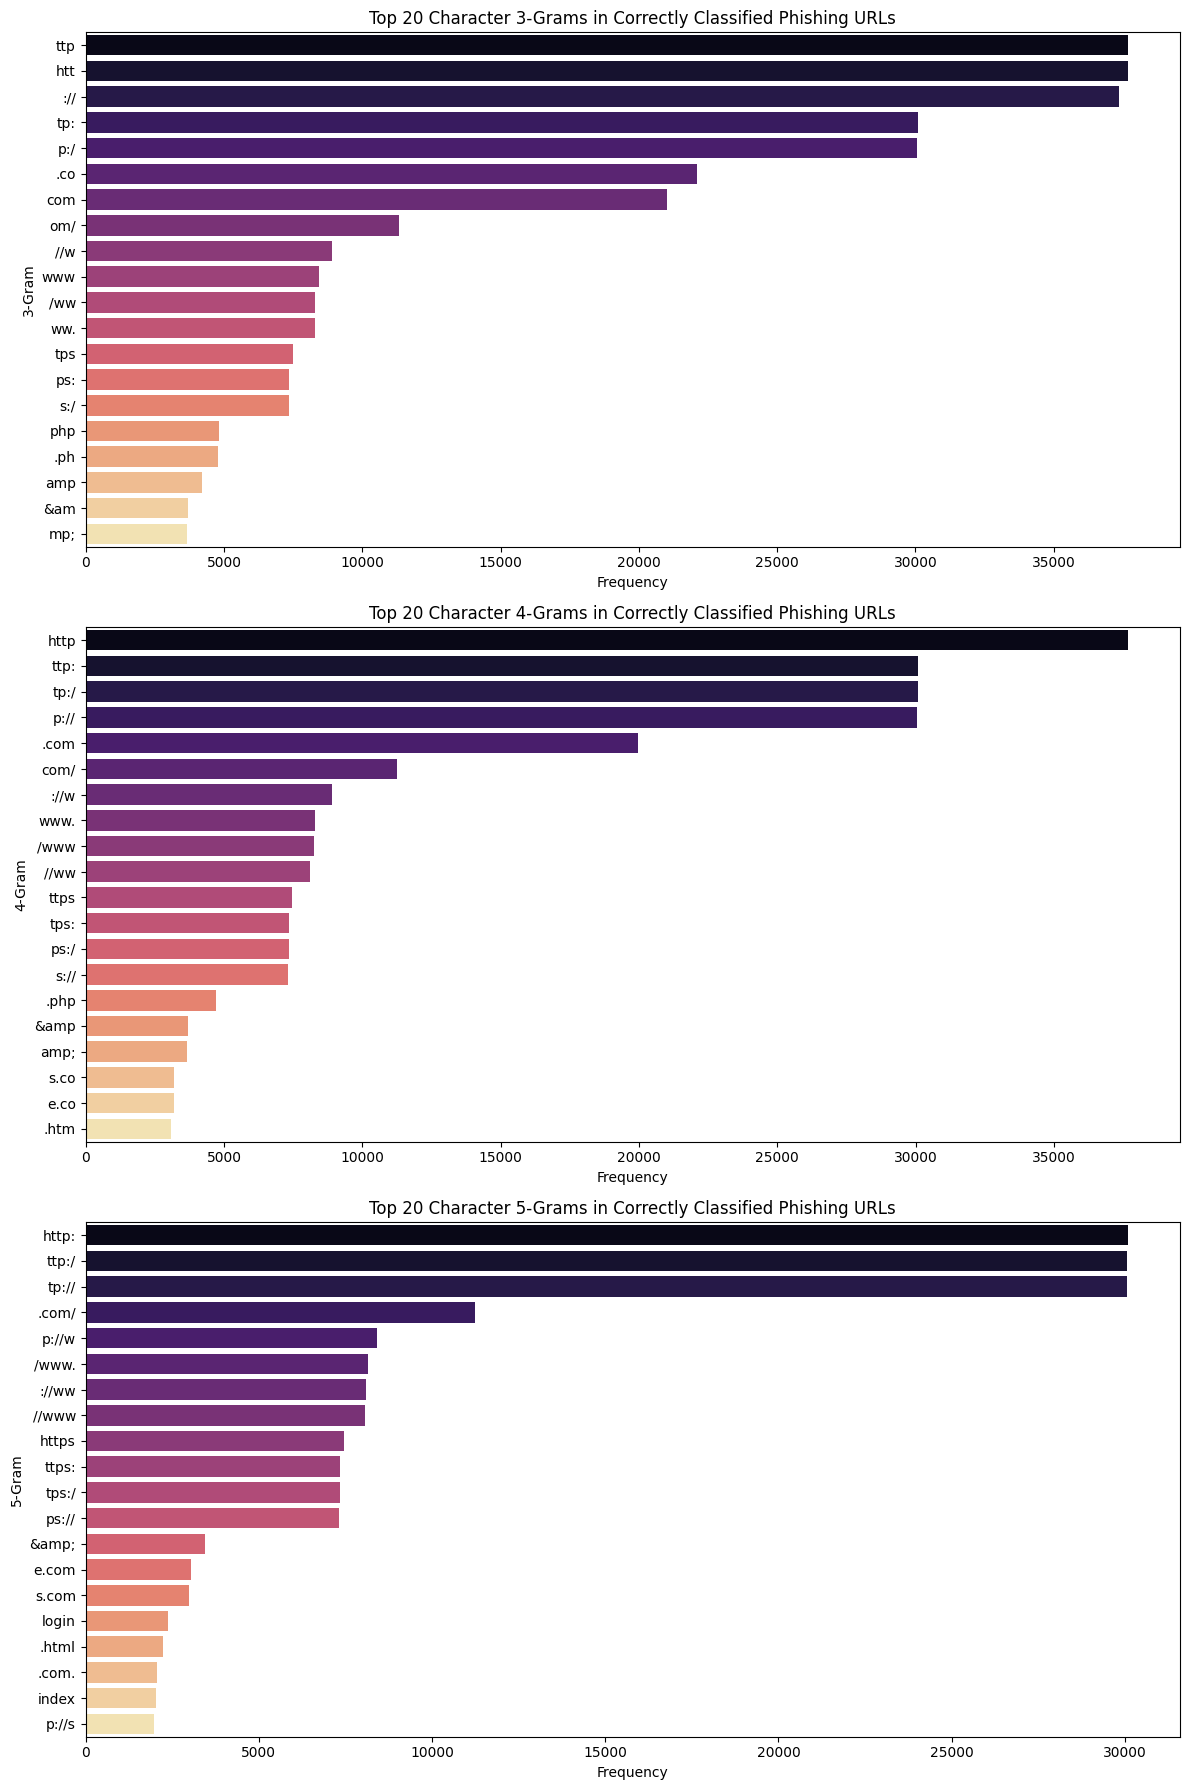

In [34]:
# Reuse the extract_ngrams function

all_phishing_ngrams = {n: Counter() for n in ngram_sizes}

for url in tqdm(correctly_classified_phishing_urls, desc="Extracting phishing n-grams"):
    for n in ngram_sizes:
        all_phishing_ngrams[n].update(extract_ngrams(url, n))

# Visualize the top N n-grams for each size for correctly classified phishing URLs
num_top_ngrams = 20

fig, axes = plt.subplots(len(ngram_sizes), 1, figsize=(12, 6 * len(ngram_sizes)))
if len(ngram_sizes) == 1:
    axes = [axes]

for i, n in enumerate(ngram_sizes):
    top_ngrams = all_phishing_ngrams[n].most_common(num_top_ngrams)
    if not top_ngrams:
        print(f"No {n}-grams found for phishing.")
        continue

    ngram_labels, ngram_counts = zip(*top_ngrams)

    sns.barplot(x=list(ngram_counts), y=list(ngram_labels), ax=axes[i], palette='magma')
    axes[i].set_title(f'Top {num_top_ngrams} Character {n}-Grams in Correctly Classified Phishing URLs')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel(f'{n}-Gram')
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

### TLD Analysis: Misclassified Legitimate vs. Correctly Classified Phishing

In [35]:
def extract_tld(url):
    """Extracts the top-level domain from a URL."""
    # Use a regular expression to find the TLD
    # This pattern attempts to capture the last part after the last dot in the domain
    import re
    match = re.search(r'\.([a-zA-Z0-9]+)(?:[/\?#]|$)', url)
    if match:
        return '.' + match.group(1)
    return None

suspicious_tlds = ['.ru', '.xyz', '.top', '.tk']
legitimate_tlds = ['.com', '.org', '.net']

# Analyze misclassified legitimate URLs
misclassified_legit_tlds = Counter()
for url in tqdm(misclassified_legitimate_urls, desc="Analyzing TLDs in misclassified legitimate URLs"):
    tld = extract_tld(url)
    if tld:
        misclassified_legit_tlds[tld] += 1

print("\n--- TLDs in Misclassified Legitimate URLs ---")
print("Top 10 TLDs:")
for tld, count in misclassified_legit_tlds.most_common(10):
    print(f"  {tld}: {count}")

print("\nCounts of specific 'legitimate' TLDs:")
for tld in legitimate_tlds:
    print(f"  {tld}: {misclassified_legit_tlds[tld]}")

print("\nCounts of specific 'suspicious' TLDs:")
for tld in suspicious_tlds:
    print(f"  {tld}: {misclassified_legit_tlds[tld]}")

Analyzing TLDs in misclassified legitimate URLs:   0%|          | 0/1247 [00:00<?, ?it/s]


--- TLDs in Misclassified Legitimate URLs ---
Top 10 TLDs:
  .com: 640
  .app: 126
  .io: 43
  .dev: 41
  .net: 39
  .site: 20
  .org: 17
  .de: 17
  .br: 17
  .link: 15

Counts of specific 'legitimate' TLDs:
  .com: 640
  .org: 17
  .net: 39

Counts of specific 'suspicious' TLDs:
  .ru: 8
  .xyz: 5
  .top: 14
  .tk: 0


In [36]:
# Analyze correctly classified phishing URLs
correctly_phishing_tlds = Counter()
for url in tqdm(correctly_classified_phishing_urls, desc="Analyzing TLDs in correctly classified phishing URLs"):
    tld = extract_tld(url)
    if tld:
        correctly_phishing_tlds[tld] += 1

print("\n--- TLDs in Correctly Classified Phishing URLs ---")
print("Top 10 TLDs:")
for tld, count in correctly_phishing_tlds.most_common(10):
    print(f"  {tld}: {count}")

print("\nCounts of specific 'legitimate' TLDs:")
for tld in legitimate_tlds:
    print(f"  {tld}: {correctly_phishing_tlds[tld]}")

print("\nCounts of specific 'suspicious' TLDs:")
for tld in suspicious_tlds:
    print(f"  {tld}: {correctly_phishing_tlds[tld]}")

Analyzing TLDs in correctly classified phishing URLs:   0%|          | 0/37007 [00:00<?, ?it/s]


--- TLDs in Correctly Classified Phishing URLs ---
Top 10 TLDs:
  .com: 16633
  .net: 1559
  .ru: 1284
  .org: 1103
  .co: 827
  .app: 760
  .br: 756
  .cn: 752
  .io: 632
  .top: 473

Counts of specific 'legitimate' TLDs:
  .com: 16633
  .org: 1103
  .net: 1559

Counts of specific 'suspicious' TLDs:
  .ru: 1284
  .xyz: 332
  .top: 473
  .tk: 75


This analysis should provide quantitative evidence for the TLD patterns you've observed, helping to confirm if `.ru`, `.xyz`, `.top`, `.tk` are indeed more prevalent in phishing URLs and `.com`, `.org`, `.net` in legitimate ones, even among those that were misclassified.

## Detailed Feature Comparison: Correctly Classified Legitimate vs. Misclassified Legitimate

To understand why some legitimate URLs are misclassified, we'll compare several structural features between:

*   **Correctly Classified Legitimate URLs:** `True Label = 1`, `Predicted Label = 1`
*   **Misclassified Legitimate URLs:** `True Label = 1`, `Predicted Label = 0` (this is `misclassified_legitimate_urls` from earlier)

We will examine:

1.  **URL length**
2.  **Domain length**
3.  **Number of subdomains**
4.  **Number of digits**
5.  **Number of hyphens**
6.  **Number of dots**
7.  **Path length**
8.  **Query length**
9.  **Character entropy**

In [37]:
from urllib.parse import urlparse
import math

# Identify correctly classified legitimate URLs
correctly_classified_legitimate_indices = np.where(
    (test_features["labels"] == 1) & (best_pred == 1)
)[0]

correctly_classified_legitimate_urls = X_test[correctly_classified_legitimate_indices]

print(f"Number of correctly classified legitimate URLs: {len(correctly_classified_legitimate_urls):,}")
print(f"Number of misclassified legitimate URLs: {len(misclassified_legitimate_urls):,}")

# Define feature extraction functions
def get_url_length(url):
    return len(url)

def get_domain_length(url):
    parsed_url = urlparse('//' + url if '://' not in url else url) # Add // for proper parsing if missing
    return len(parsed_url.netloc)

def get_num_subdomains(url):
    parsed_url = urlparse('//' + url if '://' not in url else url)
    domain_parts = parsed_url.netloc.split('.')
    # Heuristic: subtract 2 for TLD and main domain. Adjust if less than 2 parts.
    if len(domain_parts) > 2:
        return len(domain_parts) - 2
    return 0

def get_num_digits(url):
    return sum(c.isdigit() for c in url)

def get_num_hyphens(url):
    return url.count('-')

def get_num_dots(url):
    return url.count('.')

def get_path_length(url):
    parsed_url = urlparse('//' + url if '://' not in url else url)
    return len(parsed_url.path)

def get_query_length(url):
    parsed_url = urlparse('//' + url if '://' not in url else url)
    return len(parsed_url.query)

def get_character_entropy(url):
    if not url: # Avoid division by zero for empty strings
        return 0.0
    counts = Counter(url)
    probabilities = [count / len(url) for count in counts.values()]
    entropy = -sum(p * math.log2(p) for p in probabilities)
    return entropy

Number of correctly classified legitimate URLs: 78,132
Number of misclassified legitimate URLs: 1,247


In [38]:
def extract_all_features(urls_list):
    data = []
    for url in tqdm(urls_list, desc="Extracting features"):
        # Preprocess the URL the same way as the model input


        data.append({
            'url_length': get_url_length(url),
            'domain_length': get_domain_length(url),
            'num_subdomains': get_num_subdomains(url),
            'num_digits': get_num_digits(url),
            'num_hyphens': get_num_hyphens(url),
            'num_dots': get_num_dots(url),
            'path_length': get_path_length(url),
            'query_length': get_query_length(url),
            'character_entropy': get_character_entropy(url),
        })
    return pd.DataFrame(data)

print("Extracting features for correctly classified legitimate URLs...")
correct_legit_features_df = extract_all_features(correctly_classified_legitimate_urls)

print("Extracting features for misclassified legitimate URLs...")
misclassified_legit_features_df = extract_all_features(misclassified_legitimate_urls)

display(correct_legit_features_df.head())
display(misclassified_legit_features_df.head())

Extracting features for correctly classified legitimate URLs...


Extracting features:   0%|          | 0/78132 [00:00<?, ?it/s]

Extracting features for misclassified legitimate URLs...


Extracting features:   0%|          | 0/1247 [00:00<?, ?it/s]

,url_length,domain_length,num_subdomains,num_digits,num_hyphens,num_dots,path_length,query_length,character_entropy
0,23,15,1,0,0,2,0,0,3.882045
1,32,24,1,0,1,2,0,0,4.054229
2,61,26,1,0,1,3,27,0,4.283139
3,29,21,1,0,0,2,0,0,4.185230
4,312,14,2,65,0,16,17,273,5.484290


,url_length,domain_length,num_subdomains,num_digits,num_hyphens,num_dots,path_length,query_length,character_entropy
0,35,19,1,3,1,2,8,0,4.357296
1,137,39,2,11,0,3,1,88,4.714888
2,32,23,0,2,0,1,1,0,4.152518
3,45,36,1,0,1,2,1,0,4.024318
4,34,25,0,0,0,1,1,0,4.020855


Now that we have extracted the features for both groups, let's compare their statistics and visualize their distributions to identify any significant differences.

### Feature Statistics Comparison

In [39]:
print("\n--- Descriptive Statistics for Correctly Classified Legitimate URLs ---")
display(correct_legit_features_df.describe())

print("\n--- Descriptive Statistics for Misclassified Legitimate URLs ---")
display(misclassified_legit_features_df.describe())


--- Descriptive Statistics for Correctly Classified Legitimate URLs ---


,url_length,domain_length,num_subdomains,num_digits,num_hyphens,num_dots,path_length,query_length,character_entropy
count,78132.000000,78132.000000,78132.000000,78132.000000,78132.000000,78132.000000,78132.000000,78132.000000,78132.000000
mean,51.084652,19.519621,1.214458,2.767765,1.054306,2.478728,20.299736,3.148006,4.209510
std,31.997357,6.522295,0.507165,5.705071,2.383384,0.767050,24.920169,17.656422,0.370187
min,16.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.895424
25%,30.000000,15.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,3.950344
50%,43.000000,19.000000,1.000000,0.000000,0.000000,2.000000,13.000000,0.000000,4.184136
75%,62.000000,23.000000,1.000000,4.000000,1.000000,3.000000,31.000000,0.000000,4.447262
max,1519.000000,115.000000,6.000000,277.000000,41.000000,22.000000,630.000000,1401.000000,6.030422



--- Descriptive Statistics for Misclassified Legitimate URLs ---


,url_length,domain_length,num_subdomains,num_digits,num_hyphens,num_dots,path_length,query_length,character_entropy
count,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000
mean,48.389735,22.782678,0.750601,4.113873,0.716119,2.028067,10.909383,6.487570,4.179055
std,47.051393,11.570709,0.680759,11.585048,1.274993,0.996792,21.344434,39.312588,0.377940
min,15.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.006239
25%,30.000000,16.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.942113
50%,37.000000,21.000000,1.000000,0.000000,0.000000,2.000000,1.000000,0.000000,4.118485
75%,50.000000,27.000000,1.000000,4.000000,1.000000,2.000000,13.000000,0.000000,4.328530
max,835.000000,142.000000,7.000000,187.000000,14.000000,12.000000,393.000000,789.000000,5.958629


The statistics give us a good numerical summary. Now, let's visualize the distributions of these features to get a clearer picture of how they differ between the two groups. We'll use kernel density plots (KDE plots) for a smooth representation of the data distributions.

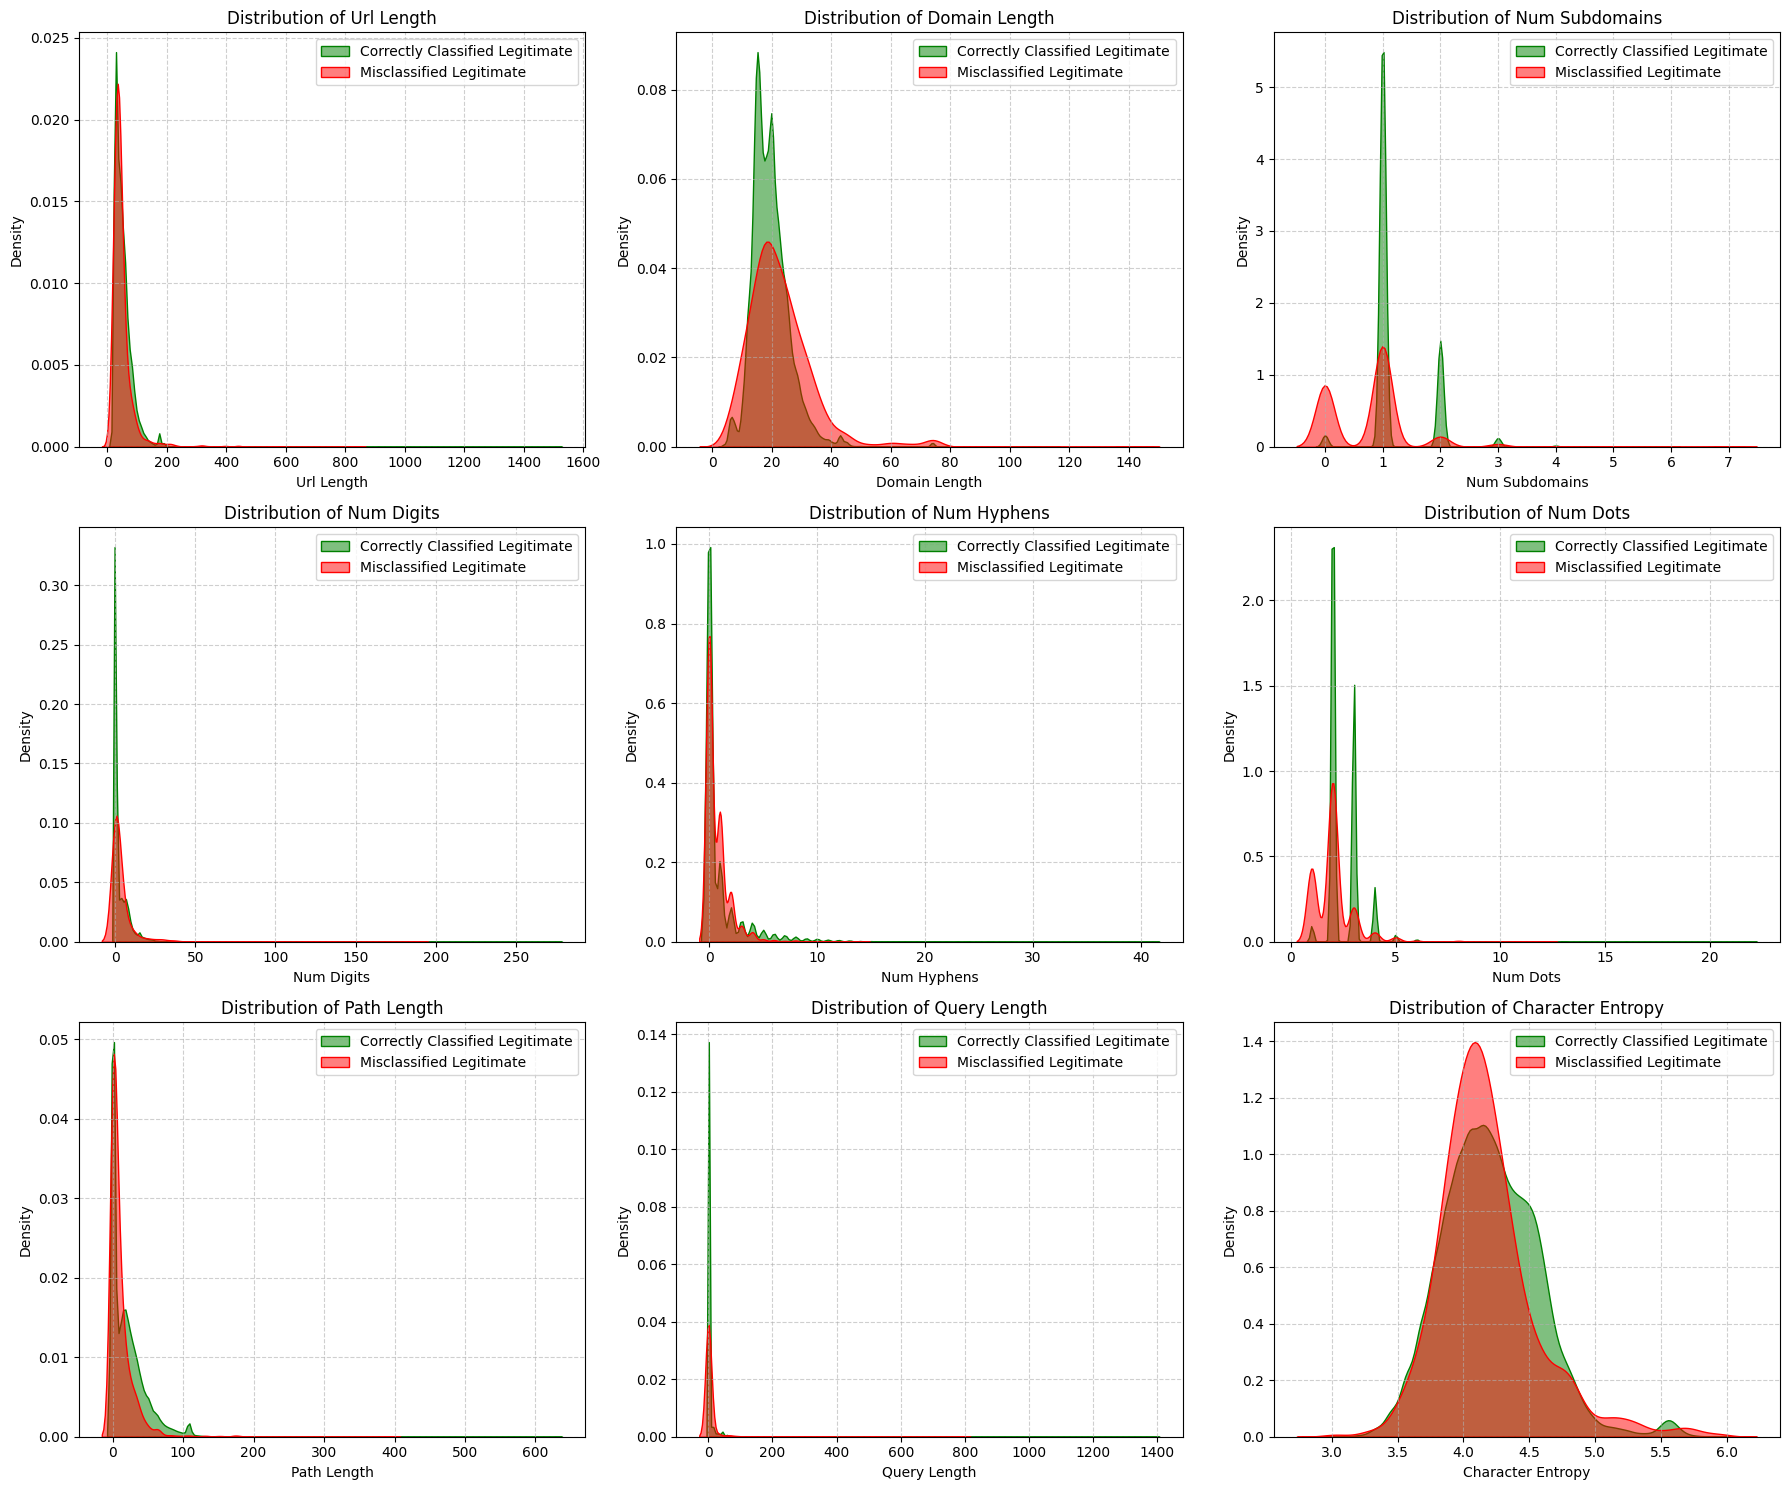

In [40]:
features_to_compare = [
    'url_length',
    'domain_length',
    'num_subdomains',
    'num_digits',
    'num_hyphens',
    'num_dots',
    'path_length',
    'query_length',
    'character_entropy'
]

plt.figure(figsize=(18, 15))
for i, feature in enumerate(features_to_compare):
    plt.subplot(3, 3, i + 1) # 3 rows, 3 columns

    sns.kdeplot(correct_legit_features_df[feature], label='Correctly Classified Legitimate', fill=True, alpha=0.5, color='green')
    sns.kdeplot(misclassified_legit_features_df[feature], label='Misclassified Legitimate', fill=True, alpha=0.5, color='red')

    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 15. Saving All Artifacts

We save everything needed to reproduce this pipeline and to run inference later, without re-training:

- CNN weights (already checkpointed during training, saved again here for clarity)
- All three ensemble models (Random Forest, XGBoost, LightGBM), plus a record of which one performed best
- The character vocabulary (`char2idx`)
- The `CONFIG` dictionary
- CNN training history (loss/accuracy curves)
- Test-set evaluation results for all three models

In [41]:
output_dir = CONFIG["output_dir"]

# 1. CNN weights (best checkpoint, already saved during training at checkpoint_path)
torch.save(model.state_dict(), os.path.join(output_dir, "char_cnn_final.pt"))

# 2. Ensemble models
with open(os.path.join(output_dir, "random_forest.pkl"), "wb") as f:
    pickle.dump(rf_model, f)

with open(os.path.join(output_dir, "xgboost.pkl"), "wb") as f:
    pickle.dump(xgb_model, f)

with open(os.path.join(output_dir, "lightgbm.pkl"), "wb") as f:
    pickle.dump(lgbm_model, f)

# 2b. Record which model performed best, so a fresh session can load it directly.
with open(os.path.join(output_dir, "best_model.json"), "w") as f:
    json.dump({"best_model_name": best_model_name}, f, indent=2)

# 3. Vocabulary
with open(os.path.join(output_dir, "vocab.json"), "w") as f:
    json.dump({"char2idx": char2idx, "idx2char": {str(k): v for k, v in idx2char.items()}}, f, indent=2)

# 4. Configuration
with open(os.path.join(output_dir, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

# 5. CNN training history
with open(os.path.join(output_dir, "training_history.json"), "w") as f:
    json.dump(history, f, indent=2)

# 6. Evaluation results (all three models)
results_df.to_csv(os.path.join(output_dir, "test_set_results.csv"))

print(f"All artifacts saved to: {output_dir}")
print(f"Best model: {best_model_name}")
print(os.listdir(output_dir))

All artifacts saved to: /content/drive/MyDrive/phishing_detection_project/artifacts
Best model: RandomForest
['features', 'char_cnn_best.pt', 'loss_curve.png', 'roc_curve.png', 'pr_curve.png', 'confusion_matrix.png', 'random_forest.pkl', 'vocab.json', 'config.json', 'test_set_results.csv', 'char_cnn_final.pt', 'training_history.json', 'ensemble_confusion_matrix.png', 'rf_deep.pkl', 'xgb_deep.pkl', 'lgbm_deep.pkl', 'xgboost.pkl', 'lightgbm.pkl', 'best_model.json']


### Reloading everything from disk for inference (fresh session)

The cell below shows how you would load all saved artifacts in a **new** Colab session, without re-running any training code above.

In [43]:
# --- Example: reloading artifacts in a fresh session ---
# (Assumes CONFIG['output_dir'] is already mounted via Google Drive.)

# 1. Load config
with open(os.path.join(output_dir, "config.json")) as f:
    loaded_config = json.load(f)

# 2. Load vocabulary
with open(os.path.join(output_dir, "vocab.json")) as f:
    vocab_data = json.load(f)
loaded_char2idx = vocab_data["char2idx"]

# 3. Rebuild the CNN architecture and load its weights
loaded_model = CharCNN(
    vocab_size=len(loaded_char2idx),
    embedding_dim=loaded_config["embedding_dim"],
    num_filters=loaded_config["num_filters"],
    kernel_sizes=loaded_config["kernel_sizes"],
    fc_hidden_dim=loaded_config["fc_hidden_dim"],
    num_classes=loaded_config["num_classes"],
    pad_idx=loaded_char2idx[loaded_config["pad_token"]],
    feature_pool_size=loaded_config["feature_pool_size"],
    dropout=loaded_config["dropout"],
).to(device)
loaded_model.load_state_dict(torch.load(
    os.path.join(output_dir, "char_cnn_final.pt"), map_location=device
))
loaded_model.eval()

# 4. Load whichever ensemble model performed best on the test set
with open(os.path.join(output_dir, "best_model.json")) as f:
    loaded_best_name = json.load(f)["best_model_name"]

best_model_files = {
    "RandomForest": "random_forest.pkl",
    "XGBoost": "xgboost.pkl",
    "LightGBM": "lightgbm.pkl",
}
with open(os.path.join(output_dir, best_model_files[loaded_best_name]), "rb") as f:
    loaded_clf_model = pickle.load(f)

print(f"All artifacts reloaded successfully (best model: {loaded_best_name}). Ready for inference.")

# Sanity check with the reloaded artifacts
predict_url(example_url, loaded_model, loaded_clf_model, loaded_char2idx, loaded_config, device)

All artifacts reloaded successfully (best model: RandomForest). Ready for inference.


{'url': 'https://www.npdlink.com',
 'predicted_class': 1,
 'predicted_label': 'legitimate',
 'probability_legitimate': 0.9986311574907782,
 'confidence': 0.9972623149815565}